## Evaluating predictions on testing data

In [1]:
import os
import sys
import importlib as imp
import numpy as np
import torch
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns
from rasterio.windows import Window
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

from utils import utils
from data_builder import data_methods
from data_builder import read_landsat
from visualizer import plots

In [2]:
print(f"python version = {sys.version}")
print(f"numpy version = {np.__version__}")
print(f"pytorch version = {torch.__version__}")

python version = 3.12.0 | packaged by conda-forge | (main, Oct  3 2023, 08:36:57) [Clang 15.0.7 ]
numpy version = 1.26.4
pytorch version = 2.1.2.post3


In [3]:
# GET config
EXP_NAME = "exp007"

config = utils.get_config(EXP_NAME)
config["mode"] = "inference"
directory_paths = utils.get_directories(config["machine"])

 --- 2020---
(631696,) (631696,)


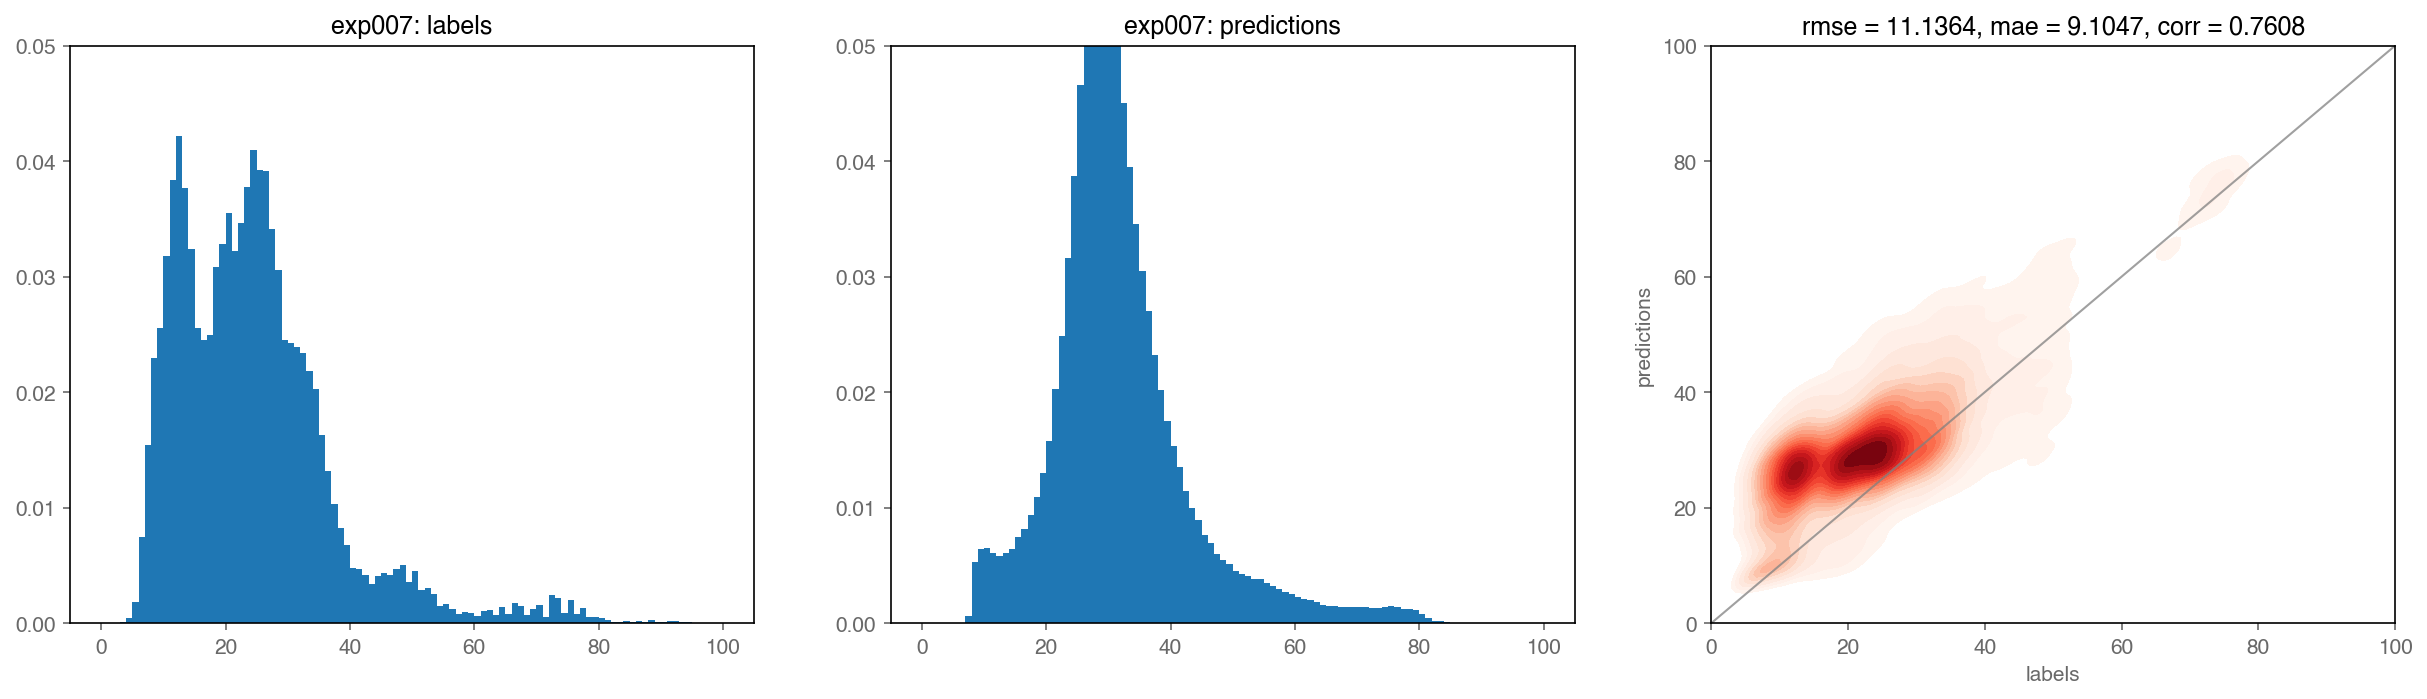

In [4]:
nsamples_to_plot = 50_000

# overwrite the inference region
# config["data"]["inference_region"] = [6, 8, 0, 5]

for year in (2020,):
    print(" --- " + str(year) + "---")
    config["inference_years"] = (year,)

    # TILE THE PREDICTIONS TOGETHER
    model_name = utils.get_model_name(config["expname"], config["seed"])
    mosaic_filename = (
        directory_paths["mosaics_dir"]
        + model_name
        + "_"
        + str(config["inference_years"][0])
        + "_mlhfi_mosaic.tif"
    )
    labels_filename = (
        directory_paths["data_dir"]
        + "hii_"
        + str(config["inference_years"][0])
        + "-01-01_uint8.tif"
    )

    with rasterio.open(mosaic_filename) as predict_tif:

        # get bounds of interest for analysis
        lat_s, lat_n, lon_w, lon_e = config["data"]["inference_region"]
        ilat_n, ilon_w = predict_tif.index(lon_w, lat_n)
        ilat_s, ilon_e = predict_tif.index(lon_e, lat_s)
        ilat_n = max(ilat_n, 0)

        window = Window.from_slices((ilat_n, ilat_s + 1), (ilon_w, ilon_e + 1))
        predictions = np.asarray(predict_tif.read(1, window=window), dtype="float")

        with rasterio.open(labels_filename) as label_tif:

            # get correct bounds to evaluate the labels
            lon_w, lat_n = predict_tif.xy(ilat_n, ilon_w, offset="ul")
            lon_e, lat_s = predict_tif.xy(ilat_s, ilon_e, offset="ul")
            ilat_n, ilon_w = label_tif.index(lon_w, lat_n)
            ilat_s, ilon_e = label_tif.index(lon_e, lat_s)

            window = Window.from_slices((ilat_n, ilat_s + 1), (ilon_w, ilon_e + 1))
            labels = np.asarray(label_tif.read(1, window=window), dtype="float")

    # REMOVE EDGES FOR NOW
    if config["inference"]["quicklook"]:
        predictions = predictions[
            config["inference"]["quicklook_skiplen"]
            * 2 : -config["inference"]["quicklook_skiplen"]
            * 2,
            config["inference"]["quicklook_skiplen"]
            * 2 : -config["inference"]["quicklook_skiplen"]
            * 2,
        ]

        labels = labels[
            config["inference"]["quicklook_skiplen"]
            * 2 : -config["inference"]["quicklook_skiplen"]
            * 2,
            config["inference"]["quicklook_skiplen"]
            * 2 : -config["inference"]["quicklook_skiplen"]
            * 2,
        ]

    else:
        predictions = predictions[7:-7, 7:-7]
        labels = labels[7:-7, 7:-7]

    # FLATTEN AND ANALYZE
    predictions = predictions.flatten()
    labels = labels.flatten()
    if config["inference"]["quicklook"]:
        predictions = predictions[:: config["inference"]["quicklook_skiplen"]]
        labels = labels[:: config["inference"]["quicklook_skiplen"]]
    predictions, labels = data_methods.remove_nodata(predictions, labels)
    print(labels.shape, predictions.shape)

    # MAKE HISTOGRAMS
    plt.figure(figsize=(20, 5))
    plt.subplot(1, 3, 1)
    bins = np.arange(0, 101, 1)
    plt.hist(labels, bins, density=True)
    plt.title(config["expname"] + ": labels")
    plt.ylim(0, 0.05)

    plt.subplot(1, 3, 2)
    bins = np.arange(0, 101, 1)
    plt.hist(predictions, bins, density=True)
    plt.title(config["expname"] + ": predictions")
    plt.ylim(0, 0.05)

    # MAKE SUMMARY FIGURE
    rmse = np.sqrt(mean_squared_error(labels, predictions)).round(4)
    mae = mean_absolute_error(labels, predictions).round(4)
    corr = np.corrcoef(labels, predictions)[0, 1].round(4)

    rng = np.random.default_rng(42)
    iplot = rng.choice(np.arange(len(predictions)), size=nsamples_to_plot)

    plt.subplot(1, 3, 3)
    sns.kdeplot(
        x=labels[iplot],
        y=predictions[iplot],
        fill=True,
        cmap="Reds",
        bw_adjust=0.75,
        levels=20,
    )
    plt.plot((0, 100), (0, 100), "-", linewidth=1, color="gray", alpha=0.75)
    plt.title(f"{rmse = }, {mae = }, {corr = }")
    plt.xlabel("labels")
    plt.ylabel("predictions")
    plt.xlim(0, 100)
    plt.ylim(0, 100)

    plots.savefig(config, str(year) + "_prediction_metrics")
    plt.show()